<a href="https://colab.research.google.com/github/YESHASWINI-R/Sentiment-Classification-Deep-Learning/blob/main/Sentiment_Analysis_on_reviews.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SENTIMENT ANALYSIS USING DEEP LEARNING-SIMPLE NEURAL NETWORK, CNN, LSTM

# Importing the libraries

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import os, json
from zipfile import ZipFile

kaggle_dictionary = json.load(open("kaggle.json"))
os.environ["KAGGLE_USERNAME"] = kaggle_dictionary["username"]
os.environ["KAGGLE_KEY"] = kaggle_dictionary["key"]

# Download IMDB 50k dataset
!kaggle datasets download -d lakshmi25npathi/imdb-dataset-of-50k-movie-reviews

# Unzip
with ZipFile("imdb-dataset-of-50k-movie-reviews.zip", "r") as zip_ref:
    zip_ref.extractall()

Dataset URL: https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews
License(s): other
  0% 0.00/25.7M [00:00<?, ?B/s]
100% 25.7M/25.7M [00:00<00:00, 1.34GB/s]


# LOAD DATASET

In [ ]:
import pandas as pd
data = pd.read_csv("IMDB Dataset.csv")
print(data.shape)
print(data.head())

(50000, 2)
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


## Map sentiment to 0/1

In [ ]:
data.replace({"sentiment": {"positive": 1, "negative": 0}}, inplace=True)
print(data["sentiment"].value_counts())

sentiment
1    25000
0    25000
Name: count, dtype: int64


/tmp/ipython-input-2055439680.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data.replace({"sentiment": {"positive": 1, "negative": 0}}, inplace=True)


# Class Distribution

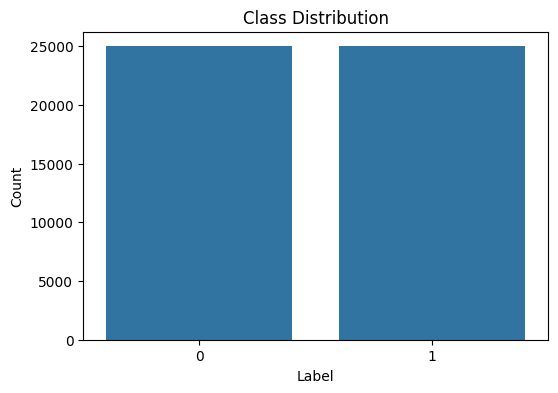

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x=data['sentiment'])
plt.title("Class Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

# Train Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X = data['review']
y = data['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (40000,)
X_test shape: (10000,)
y_train shape: (40000,)
y_test shape: (10000,)


# Tokenization & Padding

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_WORDS = 10000
MAX_LEN = 200

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_pad = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=MAX_LEN, padding='post')
X_test_pad = pad_sequences(tokenizer.texts_to_sequences(X_test), maxlen=MAX_LEN, padding='post')

y_train = y_train.values
y_test = y_test.values

print("X_train_pad shape:", X_train_pad.shape)
print("X_test_pad shape:", X_test_pad.shape)


X_train_pad shape: (40000, 200)
X_test_pad shape: (10000, 200)


# Plot Function

In [ ]:
import matplotlib.pyplot as plt

def plot_model_history(history, model_name):
    plt.figure(figsize=(12,4))

    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Validation')
    plt.title(f'{model_name} Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Validation')
    plt.title(f'{model_name} Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()


# MODEL 1 - Simple Neural Network

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Flatten, Dense

model_nn = Sequential([
    Embedding(input_dim=10000, output_dim=32, input_length=200),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_nn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_nn = model_nn.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

loss_nn, acc_nn = model_nn.evaluate(X_test_pad, y_test, verbose=0)
print("Simple NN Test Accuracy:", round(acc_nn * 100, 2), "%")

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.6653 - loss: 0.5723 - val_accuracy: 0.8706 - val_loss: 0.3013
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.9285 - loss: 0.2000 - val_accuracy: 0.8616 - val_loss: 0.3240
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - accuracy: 0.9840 - loss: 0.0653 - val_accuracy: 0.8634 - val_loss: 0.3798
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.9971 - loss: 0.0171 - val_accuracy: 0.8576 - val_loss: 0.4513
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.9998 - loss: 0.0046 - val_accuracy: 0.8531 - val_loss: 0.5284
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 1.0000 - loss: 0.0021 - val_accuracy: 0.8590 - val_loss: 0.5167
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.9999 - loss: 0.0010 - val_accuracy: 0.8593 - val_loss: 0.5369
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 1.0000 - loss: 4.9350e-04 - val_accuracy: 

In [ ]:
model_nn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (128, 200, 32)         │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (128, 6400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (128, 64)              │       409,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (128, 1)               │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,189,189 (8.35 MB)

 Trainable params: 729,729 (2.78 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,459,460 (5.57 MB)

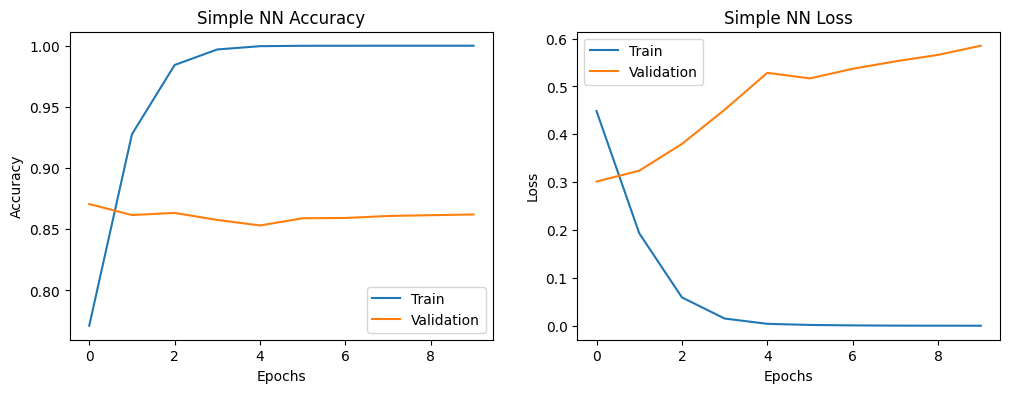

In [ ]:
plot_model_history(history_nn, "Simple NN")

# MODEL 2 - Convolutional Neural Network

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout

model_cnn = Sequential([
    Embedding(input_dim=10000, output_dim=64, input_length=200),
    Conv1D(filters=64, kernel_size=5, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model_cnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_cnn = model_cnn.fit(
    X_train_pad, y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

loss_cnn, acc_cnn = model_cnn.evaluate(X_test_pad, y_test, verbose=0)
print("CNN Test Accuracy:", round(acc_cnn * 100, 2), "%")

Epoch 1/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 35s 136ms/step - accuracy: 0.6305 - loss: 0.6177 - val_accuracy: 0.8644 - val_loss: 0.3222
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 32s 128ms/step - accuracy: 0.8947 - loss: 0.2694 - val_accuracy: 0.8930 - val_loss: 0.2627
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 40s 123ms/step - accuracy: 0.9566 - loss: 0.1410 - val_accuracy: 0.8954 - val_loss: 0.2664
Epoch 4/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 29s 116ms/step - accuracy: 0.9857 - loss: 0.0632 - val_accuracy: 0.8901 - val_loss: 0.3095
Epoch 5/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 27s 108ms/step - accuracy: 0.9967 - loss: 0.0246 - val_accuracy: 0.8915 - val_loss: 0.3545
CNN Test Accuracy: 88.85 %


In [ ]:
model_cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (128, 200, 64)         │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (128, 196, 64)         │        20,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (128, 64)              │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (128, 64)              │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (128, 64)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (128, 1)               │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,994,309 (7.61 MB)

 Trainable params: 664,769 (2.54 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,329,540 (5.07 MB)

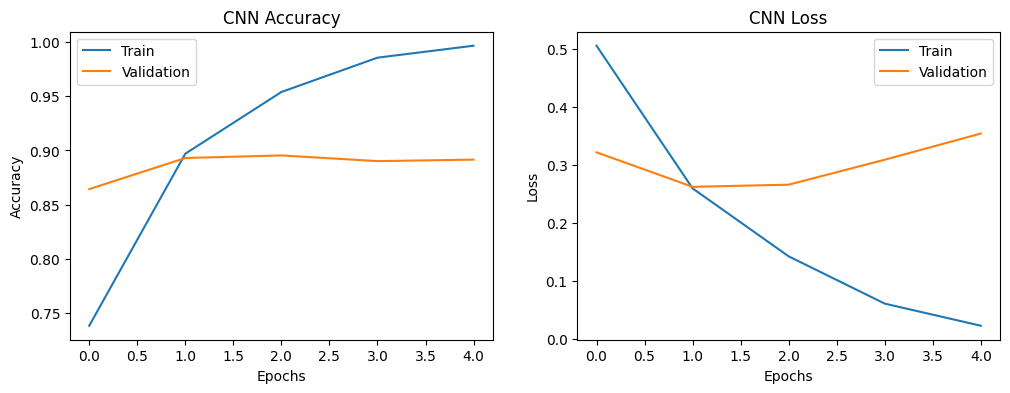

In [ ]:
plot_model_history(history_cnn, "CNN")

# MODEL 3 - Recurrent Neural Network(LSTM)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dropout, Dense
from tensorflow.keras.optimizers import Adam

model_lstm = Sequential([
    Embedding(input_dim=10000, output_dim=128, input_length=200),
    LSTM(128, dropout=0.2, recurrent_dropout=0.2),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model_lstm.compile(optimizer=Adam(learning_up rate=0.001),
                   loss='binary_crossentropy',
                   metrics=['accuracy'])

history_lstm = model_lstm.fit(
    X_train_pad, y_train,
    epochs=8,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

loss_lstm, acc_lstm = model_lstm.evaluate(X_test_pad, y_test, verbose=0)
print("LSTM Test Accuracy:", round(acc_lstm * 100, 2), "%")


Epoch 1/8
250/250 ━━━━━━━━━━━━━━━━━━━━ 332s 1s/step - accuracy: 0.5505 - loss: 0.6817 - val_accuracy: 0.6021 - val_loss: 0.6393
Epoch 2/8
250/250 ━━━━━━━━━━━━━━━━━━━━ 377s 1s/step - accuracy: 0.6765 - loss: 0.5700 - val_accuracy: 0.8079 - val_loss: 0.4499
Epoch 3/8
250/250 ━━━━━━━━━━━━━━━━━━━━ 323s 1s/step - accuracy: 0.6801 - loss: 0.5525 - val_accuracy: 0.5949 - val_loss: 0.6281
Epoch 4/8
250/250 ━━━━━━━━━━━━━━━━━━━━ 322s 1s/step - accuracy: 0.6670 - loss: 0.5584 - val_accuracy: 0.8347 - val_loss: 0.4296
Epoch 5/8
250/250 ━━━━━━━━━━━━━━━━━━━━ 323s 1s/step - accuracy: 0.7458 - loss: 0.5191 - val_accuracy: 0.7977 - val_loss: 0.4939
Epoch 6/8
250/250 ━━━━━━━━━━━━━━━━━━━━ 345s 1s/step - accuracy: 0.8529 - loss: 0.3869 - val_accuracy: 0.8604 - val_loss: 0.3431
Epoch 7/8
250/250 ━━━━━━━━━━━━━━━━━━━━ 325s 1s/step - accuracy: 0.8911 - loss: 0.2875 - val_accuracy: 0.8824 - val_loss: 0.3013
Epoch 8/8
250/250 ━━━━━━━━━━━━━━━━━━━━ 325s 1s/step - accuracy: 0.9244 - loss: 0.2169 - val_accuracy: 0.

In [ ]:
model_lstm.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (128, 200, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (128, 128)             │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (128, 128)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (128, 64)              │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (128, 64)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (128, 1)               │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,259,717 (16.25 MB)

 Trainable params: 1,419,905 (5.42 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,839,812 (10.83 MB)

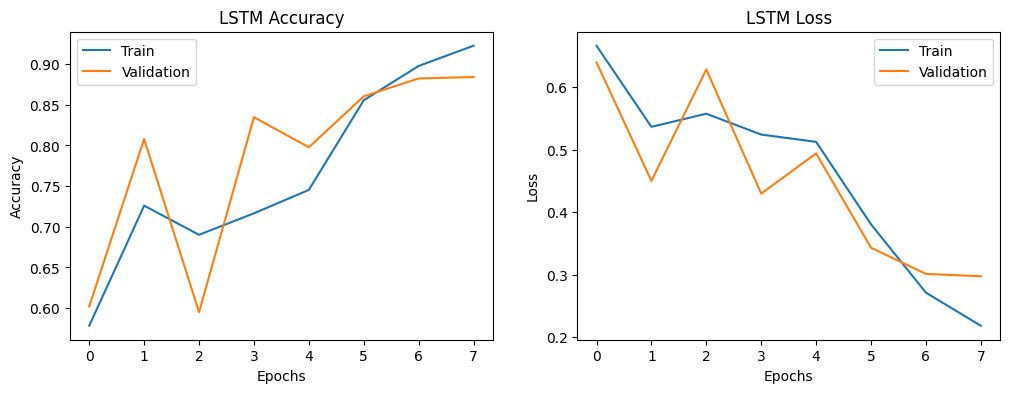

In [ ]:
plot_model_history(history_lstm, "LSTM")

# Prediction Function - LSTM

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

def predict_sentiment_lstm(sentence, tokenizer, max_len=200):
    seq = tokenizer.texts_to_sequences([sentence])
    padded = pad_sequences(seq, maxlen=max_len)
    pred = model_lstm.predict(padded, verbose=0)[0][0]
    sentiment = "positive" if pred > 0.5 else "negative"
    return sentiment

# Examples

In [ ]:
sentence = "I absolutely loved this movie! It was fantastic."

print("Sentence:", sentence)
print("Predicted Sentiment:", predict_sentiment_lstm(sentence, tokenizer))


Sentence: I absolutely loved this movie! It was fantastic.
Predicted Sentiment: positive


In [ ]:
sentence = "This movie was boring and a complete waste of time."

print("Sentence:", sentence)
print("Predicted Sentiment:", predict_sentiment_lstm(sentence, tokenizer))


Sentence: This movie was boring and a complete waste of time.
Predicted Sentiment: negative
